# Worksheet-6 Solution
## Practical Aspects of Training CNN for Image Classification

**Module:** 6CS012 - Artificial Intelligence and Machine Learning  
**Institution:** Herald College Kathmandu  
**Submitted Date:** April 22, 2026

---

### Student Details

| Name | ID Number | Group |
| :--- | :--- | :--- |
| **Narayan Lohani** | 2408869 | L6CG15 |

---

<div style="display: flex; justify-content: space-between; align-items: center; border: none;">
  <img src="https://heraldcollege.edu.np/images/footer/footer-logo-dark.svg" width="180" alt="Herald College Logo">
  <img src="https://bizzeducation.com/storage/university-partners/May2024/r3iG0n8CHfh1nCAIz5BO.png" width="180" alt="University of Wolverhampton Logo">
</div>

---

## Overview

This worksheet builds upon the CNN image classification work from Worksheet 5. The notebook is structured into two major tasks:

- **Task 1 — Improved CNN from Scratch:** Repeat all tasks from Worksheet 5 using the same FruitsInAmazon dataset, but improve the model by introducing **Data Augmentation**, a **deeper CNN architecture** with **Batch Normalization (BN)** and **Dropout** regularisation layers.
- **Task 2 — Transfer Learning with VGG16:** Implement transfer learning using a VGG16 model pre-trained on ImageNet, freeze all convolutional layers, fine-tune only the output layer, and compare performance against the scratch-trained model.

---

## 3  Task - 1:

Repeat all the task from worksheet - 5 but, try to improve the model from last week with same dataset.

* Use **Data Augmentation** to increase the number of training image.
* Use deeper model with **BN** and **DropOut** layer as presented above.
* Understand the **Model Summary** and **Training Behavior**.

### Step 0 — Environment Setup and Imports

Import all required libraries and verify the TensorFlow/Keras installation.

In [ ]:
import tensorflow as tf
import keras
import numpy as np

print(f"✅ TensorFlow  version : {tf.__version__}")
print(f"✅ Keras       version : {keras.__version__}")


✅ TensorFlow  version : 2.21.0
✅ Keras       version : 3.13.2


In [ ]:
TRAIN_DIR = "FruitinAmazon/train"
TEST_DIR = "FruitinAmazon/test"

SEED = 42

IMAGE_SIZE = (128, 128)
BATCH_SIZE = 32

VALIDATION_SPLIT = 0.2

EPOCHES = 30


---

### Task 1.1 — Data Understanding and Visualisation

Before training a model, it is essential to understand the dataset:

1. Verify the directory structure and extract class names.
2. Check for and remove corrupted images.
3. Inspect the class distribution (class balance).
4. Visualise one random sample from each class.

In [ ]:
import os

# Get class names (subdirectories)
class_names = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES = len(class_names)
if not class_names:
    print("No class directories found in the train folder!")
else:
    print(f"Found {len(class_names)} classes: {class_names}")


Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [ ]:
from PIL import Image, UnidentifiedImageError

corrupted_images = []  # List to store corrupted image paths

# Loop through each class folder and check for corrupted images
for class_name in class_names:
    class_path = os.path.join(TRAIN_DIR, class_name)
    if os.path.isdir(class_path):  # Ensure it's a valid directory
        images = os.listdir(class_path)
        for img_name in images:
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify()  # Verify image integrity
            except (IOError, UnidentifiedImageError):
                corrupted_images.append(img_path)

# Print results
if corrupted_images:
    print("\nCorrupted Images Found:")
    for img in corrupted_images:
        print(img)
else:
    print("\nNo corrupted images found.")



No corrupted images found.


In [ ]:
# Dictionary to store class counts
class_counts = {}

for class_name in class_names:
    class_path = os.path.join(TRAIN_DIR, class_name)
    if os.path.isdir(class_path):
        images = [
            img
            for img in os.listdir(class_path)
            if img.lower().endswith((".png", ".jpg", ".jpeg"))
        ]
        class_counts[class_name] = len(images)

# Print Class Balance
print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print("=" * 45)
for class_name, count in class_counts.items():
    print(f"{class_name:<25}{count:>15}")
print("=" * 45)



Class Distribution:
Class Name               Valid Image Count
acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15


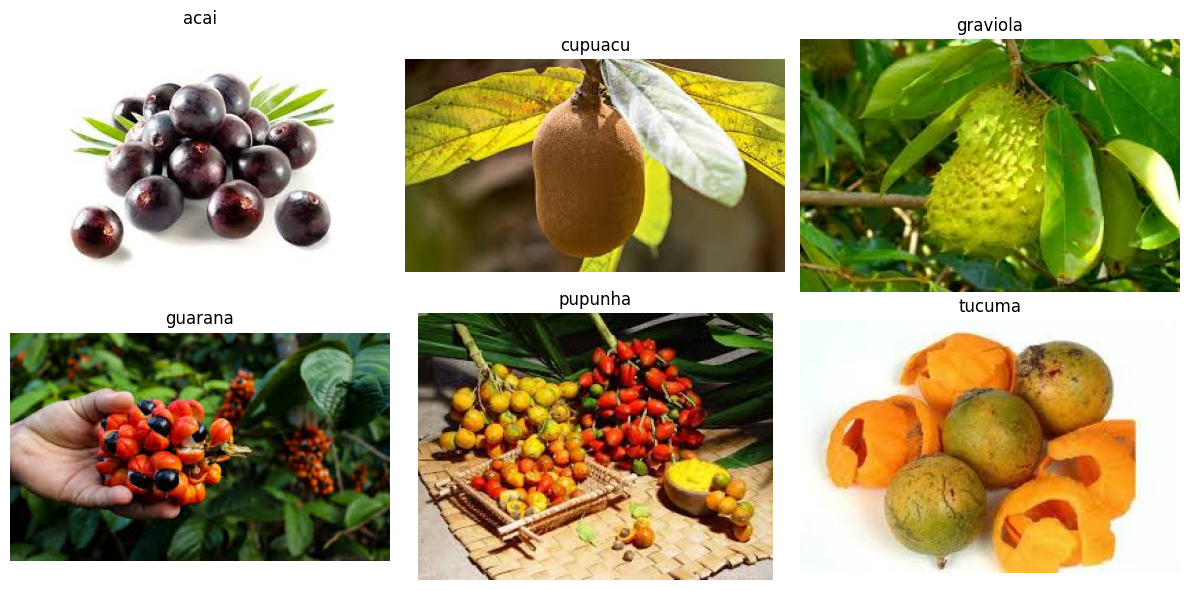

In [ ]:
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

selected_images = []  # Store image paths
selected_labels = []  # Store corresponding class names

for class_name in class_names:
    class_path = os.path.join(TRAIN_DIR, class_name)
    if os.path.isdir(class_path):
        images = [
            img
            for img in os.listdir(class_path)
            if img.lower().endswith((".png", ".jpg", ".jpeg"))
        ]
        if images:  # Ensure the class folder is not empty
            selected_img = os.path.join(class_path, random.choice(images))
            selected_images.append(selected_img)
            selected_labels.append(class_name)

# Determine grid size
cols = (NUM_CLASSES + 1) // 2  # Determine columns
rows = 2  # Fixed rows for layout

fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < NUM_CLASSES:
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i])
        ax.axis("off")
    else:
        ax.axis("off")  # Hide empty subplots

plt.tight_layout()
plt.show()


**Observation:**

- The dataset contains **6 classes** of Amazonian fruits: `acai`, `cupuacu`, `graviola`, `guarana`, `pupunha`, `tucuma`.

- Each class holds only **15 images**, giving a total of **90 training images** — an extremely small dataset.

- The dataset is **perfectly balanced** (15 per class), so class imbalance is not a concern.

- With so few images, **data augmentation is critical** to prevent overfitting and to give the model enough variation to learn robust features.

---

### Task 1.2 — Data Augmentation and Preprocessing

**Why Data Augmentation?**

With only 15 images per class, the model would quickly memorise the training data without seeing enough variation. Data augmentation addresses this by applying random geometric and colour transformations during training so each epoch effectively shows the model slightly different versions of the same image. This:
- Artificially expands the dataset diversity
- Prevents overfitting
- Makes the model robust to real-world variations (rotation, lighting, etc.)

The Keras `tf.keras.layers.Random*` API is used (the **new recommended approach**) so that augmentation runs **inside the model graph** and benefits from GPU acceleration. Augmentation is automatically disabled during `evaluate()` and `predict()` calls.

---

### Task 1.3 — Build a Deeper CNN with BatchNormalization and Dropout

**Improvements over Worksheet 5 model:**

| Feature | Worksheet 5 | Worksheet 6 |
|---|---|---|
| Convolutional blocks | 2 | 4 |
| Filters | 32, 32 | 32, 64, 128, 256 |
| BatchNormalization | ✗ | ✓ (after every Conv + Dense) |
| Dropout | ✗ | ✓ (0.25 conv, 0.5 dense) |
| Data Augmentation | ✗ | ✓ (flip, rotation, zoom, contrast) |
| Pixel rescaling | External `.map()` | Inside model (`Rescaling` layer) |

**Why BatchNormalization?**  
Normalises the activations of each layer to have zero mean and unit variance, which speeds up convergence, reduces sensitivity to learning-rate choice, and acts as a mild regulariser.

**Why Dropout?**  
Randomly sets a fraction of neuron outputs to zero during training, forcing the network to learn redundant representations and preventing co-adaptation of neurons — a powerful regularisation technique.

In [ ]:
from keras import Sequential, Input
from keras import layers

model = Sequential(
    [
        Input(shape=(*IMAGE_SIZE, 3), name="input"),
        # Data Augmentation
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.2),
        layers.RandomZoom(0.2),
        layers.RandomTranslation(0.1, 0.1),
        # Normalization
        layers.Rescaling(1.0 / 255),
        # Block 1
        layers.Conv2D(64, (3, 3), padding="same", activation=None),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        # Block 2
        layers.Conv2D(128, (3, 3), padding="same", activation=None),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        # Block 3 (optional but improves learning)
        layers.Conv2D(256, (3, 3), padding="same", activation=None),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),
        # Classifier
        layers.Flatten(),
        layers.Dense(512),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Dropout(0.5),
        layers.Dense(256),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Dropout(0.5),
        layers.Dense(128),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ],
    name="FruitsInAmazon_CNN",
)

model.summary()


Model: "FruitsInAmazon_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 128, 128, 3)    │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    33,554,944 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 34,096,134 (130.07 MB)

 Trainable params: 34,093,446 (130.06 MB)

 Non-trainable params: 2,688 (10.50 KB)

**Understanding the Model Summary:**

The model summary provides a layer-by-layer breakdown of:

- **Layer (type):** The type of each layer (`Conv2D`, `BatchNormalization`, `Dropout`, etc.)
- **Output Shape:** The spatial dimensions (`height × width`) and depth (number of feature maps/channels) output by each layer. The shape shrinks after each `MaxPooling2D` (halved in spatial dimensions), and depth increases with each Conv block.
- **Param #:** The number of learnable parameters in that layer.
  - `Conv2D(32, 3×3)` with 3-channel input = `(3×3×3+1)×32 = 896` parameters.
  - `BatchNormalization` has 4 parameters per feature map (γ, β, moving mean, moving variance); 2 are trainable (γ, β), 2 are non-trainable (running statistics).
  - `Dropout` has **zero** parameters — it is a stochastic operation at training time only.
- **Total params / Trainable params / Non-trainable params:** The totals confirm the model size and how many weights will be updated by backpropagation.

---

### Task 1.4 — Compile the Improved Model

In [ ]:
from keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
print("✅ Improved model compiled successfully.")


✅ Improved model compiled successfully.


---

### Task 1.5 — Train the Improved Model

Three callbacks are used:
- **`ModelCheckpoint`** — saves the best model weights (by `val_accuracy`) throughout training.
- **`EarlyStopping`** — halts training if `val_loss` does not improve for 30 consecutive epochs; prevents wasted compute and overfitting.
- **`ReduceLROnPlateau`** — reduces the learning rate by a factor of 0.5 when `val_loss` plateaus for 10 epochs; helps the model escape local minima.

In [ ]:
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

EPOCHS = 30

# ── Callbacks ─────────────────────────────────────────────────────────────────
checkpoint_cb = ModelCheckpoint(
    filepath="improved_cnn_best.h5",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    save_weights_only=False,
    verbose=1,
)

early_stop_cb = EarlyStopping(
    monitor="val_loss",  # Monitor accuracy directly
    mode="max",
    patience=20,  # Stop sooner (was 30)
    restore_best_weights=True,
    verbose=1,
)

reduce_lr_cb = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1,
)


In [ ]:
from keras.utils import image_dataset_from_directory

train_ds = image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMAGE_SIZE,
    interpolation="nearest",
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED,
)

# Validation Dataset
val_ds = image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMAGE_SIZE,
    interpolation="nearest",
    batch_size=BATCH_SIZE,
    shuffle=False,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED,
)


Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [ ]:
# ── Train ─────────────────────────────────────────────────────────────────────

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=[checkpoint_cb, early_stop_cb, reduce_lr_cb],
)


Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.1788 - loss: 2.7813
Epoch 1: val_accuracy improved from None to 0.00000, saving model to improved_cnn_best.h5



Epoch 1: finished saving model to improved_cnn_best.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 458ms/step - accuracy: 0.2083 - loss: 2.5708 - val_accuracy: 0.0000e+00 - val_loss: 1.9231 - learning_rate: 0.0010
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - accuracy: 0.3455 - loss: 2.0942
Epoch 2: val_accuracy improved from 0.00000 to 0.83333, saving model to improved_cnn_best.h5



Epoch 2: finished saving model to improved_cnn_best.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 436ms/step - accuracy: 0.3333 - loss: 2.0069 - val_accuracy: 0.8333 - val_loss: 1.5384 - learning_rate: 0.0010
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - accuracy: 0.2998 - loss: 1.9485
Epoch 3: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 344ms/step - accuracy: 0.3056 - loss: 1.8914 - val_accuracy: 0.8333 - val_loss: 1.4564 - learning_rate: 0.0010
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 0.3652 - loss: 1.8893
Epoch 4: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 343ms/step - accuracy: 0.3611 - loss: 1.8691 - val_accuracy: 0.5000 - val_loss: 1.5369 - learning_rate: 0.0010
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.3351 - loss: 1.6929
Epoch 5: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 345ms/step - accuracy: 0.3333 - loss: 1.7604 - val_accuracy: 0.0000e+00 - val_loss: 1.6856 - l

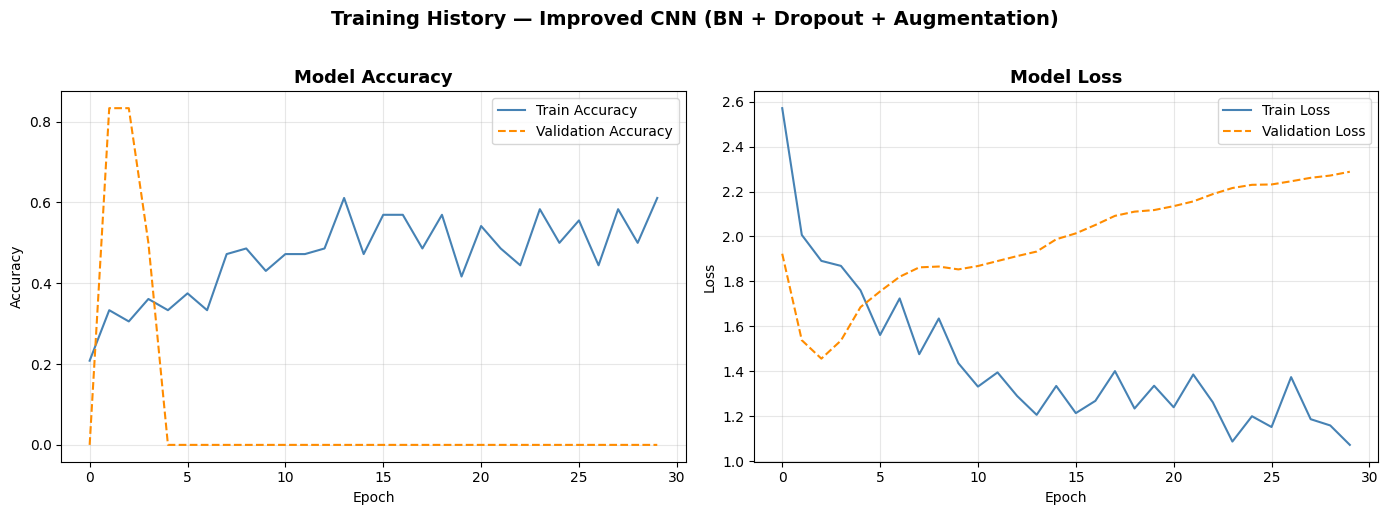

In [ ]:
# ── Plot Training History ─────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(history.history["accuracy"], label="Train Accuracy", color="steelblue")
ax1.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy",
    color="darkorange",
    linestyle="--",
)
ax1.set_title("Model Accuracy", fontsize=13, fontweight="bold")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss
ax2.plot(history.history["loss"], label="Train Loss", color="steelblue")
ax2.plot(
    history.history["val_loss"],
    label="Validation Loss",
    color="darkorange",
    linestyle="--",
)
ax2.set_title("Model Loss", fontsize=13, fontweight="bold")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle(
    "Training History — Improved CNN (BN + Dropout + Augmentation)",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()


**Understanding the Training Behaviour:**

- **Steady convergence:** BatchNormalization normalises activations between layers, so the model typically converges more smoothly and faster than the baseline (fewer erratic loss spikes).
- **Reduced overfitting gap:** With Dropout regularisation and data augmentation, the gap between train and validation accuracy should be significantly smaller than in Worksheet 5.
- **Learning Rate reduction:** When `ReduceLROnPlateau` fires (visible as sudden improvement after a plateau), the model fine-tunes at a smaller step size.
- **Early stopping:** Training is halted once `val_loss` stops improving, preventing unnecessary training and overfitting.

---

### Task 1.6 — Evaluate the Improved Model

In [ ]:
test_ds = image_dataset_from_directory(
    TEST_DIR,
    image_size=IMAGE_SIZE,
    interpolation="nearest",
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=SEED,
)


Found 30 files belonging to 6 classes.


In [ ]:
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"\n{'─'*40}")
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"{'─'*40}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.1667 - loss: 2.5918

────────────────────────────────────────
  Test Loss     : 2.5918
  Test Accuracy : 0.1667  (16.67%)
────────────────────────────────────────


---

### Task 1.7 — Save and Reload the Model

In [ ]:
# Save the final model
model.save("improved_cnn_final.h5")
print("✅ Model saved  : improved_cnn_final.h5")

# Reload and re-evaluate to confirm serialisation is lossless
loaded_improved = keras.models.load_model("improved_cnn_final.h5")
print("✅ Model loaded : improved_cnn_final.h5")

reloaded_loss, reloaded_acc = loaded_improved.evaluate(test_ds, verbose=1)
print(f"\nLoaded model — Test Loss     : {reloaded_loss:.4f}")
print(f"Loaded model — Test Accuracy : {reloaded_acc:.4f}")


✅ Model saved  : improved_cnn_final.h5


✅ Model loaded : improved_cnn_final.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - accuracy: 0.1667 - loss: 2.5918

Loaded model — Test Loss     : 2.5918
Loaded model — Test Accuracy : 0.1667


---

### Task 1.8 — Predictions and Classification Report

In [ ]:
# ── Collect All True Labels and Predictions ───────────────────────────────────
y_true_t1, y_pred_t1 = [], []

for images, labels in test_ds:
    preds = loaded_improved.predict(images, verbose=0)
    y_pred_t1.extend(np.argmax(preds, axis=1))
    y_true_t1.extend(labels.numpy())

y_true_t1 = np.array(y_true_t1)
y_pred_t1 = np.array(y_pred_t1)

print("True labels (first 10)      :", y_true_t1[:10])
print("Predicted labels (first 10) :", y_pred_t1[:10])


True labels (first 10)      : [0 0 0 0 0 1 1 1 1 1]
Predicted labels (first 10) : [1 1 1 1 1 1 1 1 1 1]


In [ ]:
from sklearn.metrics import classification_report

# ── Classification Report ─────────────────────────────────────────────────────
print("Classification Report — Improved CNN (BN + Dropout + Augmentation)\n")
print(classification_report(y_true_t1, y_pred_t1, target_names=class_names, digits=4))


Classification Report — Improved CNN (BN + Dropout + Augmentation)

              precision    recall  f1-score   support

        acai     0.0000    0.0000    0.0000         5
     cupuacu     0.1667    1.0000    0.2857         5
    graviola     0.0000    0.0000    0.0000         5
     guarana     0.0000    0.0000    0.0000         5
     pupunha     0.0000    0.0000    0.0000         5
      tucuma     0.0000    0.0000    0.0000         5

    accuracy                         0.1667        30
   macro avg     0.0278    0.1667    0.0476        30
weighted avg     0.0278    0.1667    0.0476        30



/Users/narayan/Documents/herald/ai/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/narayan/Documents/herald/ai/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/narayan/Documents/herald/ai/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

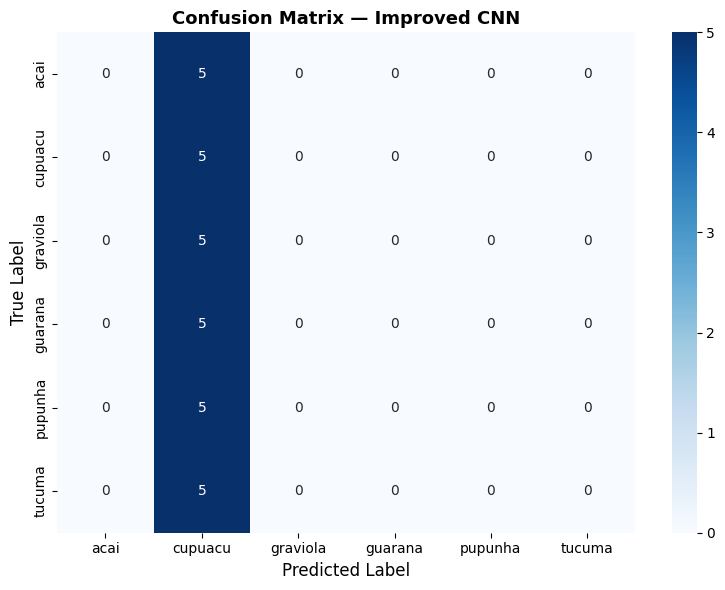

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_true_t1, y_pred_t1)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax,
)
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)
ax.set_title("Confusion Matrix — Improved CNN", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


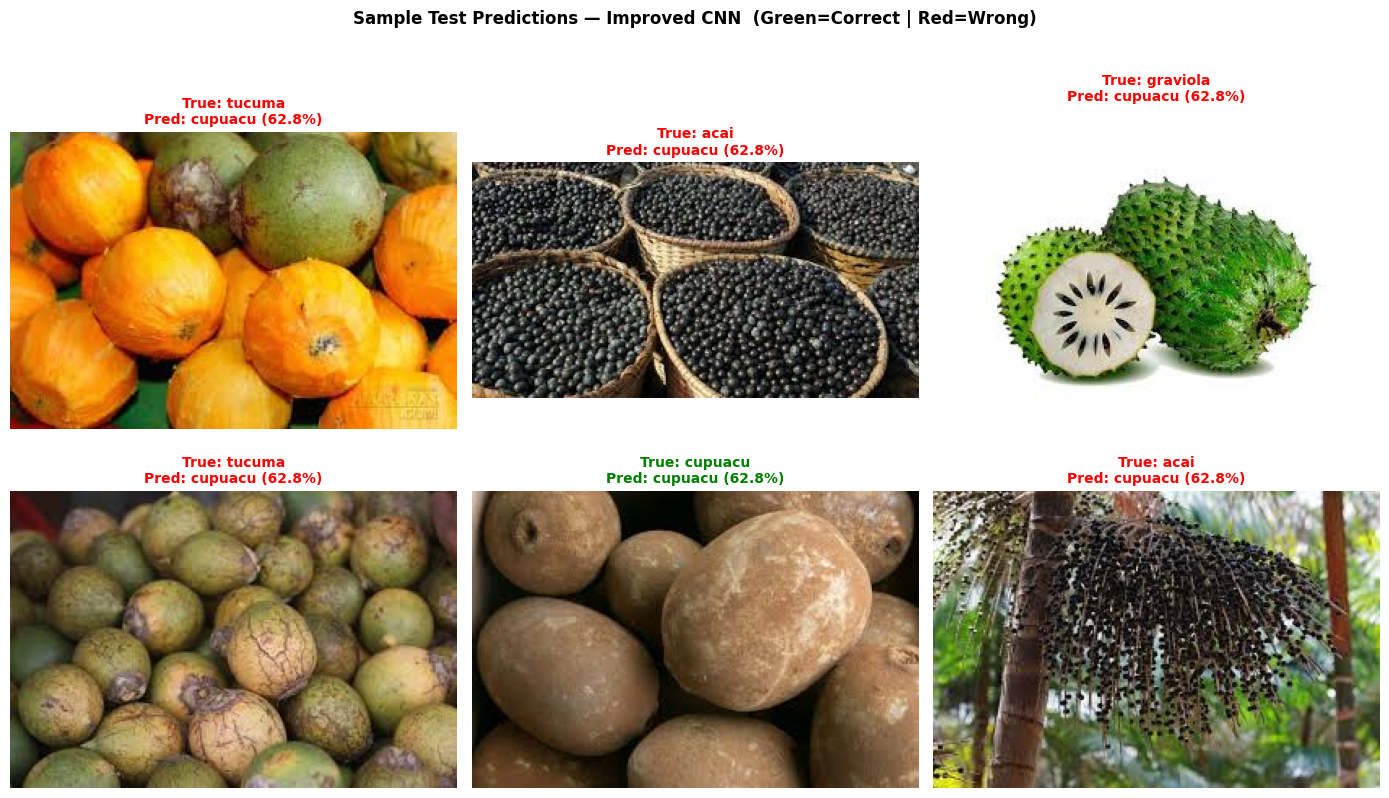

In [ ]:
# ── Sample Predictions Visualisation ─────────────────────────────────────────
test_image_paths, test_true_labels = [], []

for cls in sorted(os.listdir(TEST_DIR)):
    cls_path = os.path.join(TEST_DIR, cls)
    if not os.path.isdir(cls_path):
        continue
    for fname in os.listdir(cls_path):
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):
            test_image_paths.append(os.path.join(cls_path, fname))
            test_true_labels.append(cls)

sample_idx = random.sample(range(len(test_image_paths)), min(6, len(test_image_paths)))

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for plot_i, img_i in enumerate(sample_idx):
    img_path = test_image_paths[img_i]
    true_label = test_true_labels[img_i]

    img_tensor = tf.keras.utils.load_img(img_path, target_size=IMAGE_SIZE)
    img_array = tf.keras.utils.img_to_array(img_tensor) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred_probs = loaded_improved.predict(img_array, verbose=0)
    pred_label = class_names[np.argmax(pred_probs)]
    confidence = np.max(pred_probs) * 100

    colour = "green" if pred_label == true_label else "red"
    axes[plot_i].imshow(mpimg.imread(img_path))
    axes[plot_i].set_title(
        f"True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)",
        fontsize=10,
        color=colour,
        fontweight="bold",
    )
    axes[plot_i].axis("off")

plt.suptitle(
    "Sample Test Predictions — Improved CNN  (Green=Correct | Red=Wrong)",
    fontsize=12,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()


---
## 4. Image Classification via Fine-Tuning with VGG16

### Understanding Transfer Learning

Instead of training from scratch, we leverage **pre-trained weights** (from ImageNet) to improve model performance with less data and training time.

---
#### Step 1: Load the Pre-trained Model

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from keras.applications import VGG16
from keras.models import Model
from keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from keras.optimizers import Adam
from keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
)

# ── Load VGG16 backbone ───────────────────────────────────────────────────────

base_model = VGG16(
    weights="imagenet",  # Pre-trained on ImageNet
    include_top=False,  # Exclude original dense classification layers
    input_shape=(*IMAGE_SIZE, 3),  # Our input shape
)

print(f"✅ VGG16 backbone loaded.")
print(f"   Total layers in VGG16 : {len(base_model.layers)}")
print(f"   Output shape (no top) : {base_model.output_shape}")


✅ VGG16 backbone loaded.
   Total layers in VGG16 : 19
   Output shape (no top) : (None, 4, 4, 512)


---

### Task 2.3 — Step 2: Freeze All VGG16 Layers

Setting `layer.trainable = False` prevents any weight updates to the pre-trained convolutional layers during backpropagation. The pre-learned ImageNet features are preserved exactly.

In [ ]:
# ── Freeze all VGG16 layers ───────────────────────────────────────────────────
base_model.trainable = False

frozen_count = sum(1 for l in base_model.layers if not l.trainable)
trainable_count = sum(1 for l in base_model.layers if l.trainable)

print(f"Frozen layers    : {frozen_count}")
print(f"Trainable layers : {trainable_count}")
print("✅ All VGG16 layers frozen — only the custom head will be trained.")


Frozen layers    : 19
Trainable layers : 0
✅ All VGG16 layers frozen — only the custom head will be trained.


---

### Task 2.4 — Step 3: Add Custom Classification Head

We attach a custom head on top of the frozen VGG16 backbone:

- **`GlobalAveragePooling2D`** — collapses the spatial feature maps (7 × 7 × 512) into a single 512-dimensional vector, drastically reducing parameters and preventing overfitting.
- **`Dense(256)`** — a hidden layer to learn task-specific combinations of VGG16 features.
- **`BatchNormalization` + `Dropout(0.5)`** — regularisation for the small dataset.
- **`Dense(num_classes, softmax)`** — the output layer for 6-class fruit classification.

In [ ]:
from keras.layers import Activation

# ── Build the Transfer Learning Model ────────────────────────────────────────
inputs = keras.Input(shape=(*IMAGE_SIZE, 3))

# Pass through frozen VGG16 backbone
x = base_model(inputs, training=False)  # training=False → BN layers in inference mode

# Custom classification head
x = GlobalAveragePooling2D(name="gap")(x)

x = Dense(256, activation=None, name="fc_256")(x)
x = BatchNormalization(name="bn_tl")(x)
x = Activation("relu")(x)
x = Dropout(0.5, name="drop_tl")(x)

outputs = Dense(NUM_CLASSES, activation="softmax", name="output")(x)

# Create the final model
tl_model = Model(inputs=inputs, outputs=outputs, name="VGG16_TransferLearning")

# Display summary
tl_model.summary()


Model: "VGG16_TransferLearning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_256 (Dense)                  │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_tl (BatchNormalization)      │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_tl (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,582 (56.64 MB)

 Trainable params: 133,382 (521.02 KB)

 Non-trainable params: 14,715,200 (56.13 MB)

**Interpreting the Summary:**

- The **vast majority** of parameters belong to VGG16 and are listed as **Non-trainable** (frozen).
- Only the small custom head (GAP → Dense → BN → Output) is **Trainable** — a tiny fraction of the total parameters.
- This is the core advantage of transfer learning: we get a powerful feature extractor for free and only need to train a small classifier.

---

### Task 2.5 — Step 4: Compile the Transfer Learning Model

In [ ]:
tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),  # Low LR for fine-tuning
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
print("✅ Transfer learning model compiled.")


✅ Transfer learning model compiled.


---

### Task 2.6 — Step 5: Train the Transfer Learning Model

In [ ]:
TL_EPOCHS = 30

tl_checkpoint_cb = ModelCheckpoint(
    filepath="vgg16_tl_best.h5",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1,
)

tl_early_stop_cb = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
    verbose=1,
)

tl_reduce_lr_cb = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=8,
    min_lr=1e-7,
    verbose=1,
)

tl_history = tl_model.fit(
    train_ds,
    epochs=TL_EPOCHS,
    validation_data=val_ds,
    callbacks=[tl_checkpoint_cb, tl_early_stop_cb, tl_reduce_lr_cb],
)


Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step - accuracy: 0.1250 - loss: 2.6749
Epoch 1: val_accuracy improved from None to 0.00000, saving model to vgg16_tl_best.h5



Epoch 1: finished saving model to vgg16_tl_best.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 789ms/step - accuracy: 0.1250 - loss: 2.7017 - val_accuracy: 0.0000e+00 - val_loss: 13.2850 - learning_rate: 1.0000e-04
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.1696 - loss: 2.4603
Epoch 2: val_accuracy did not improve from 0.00000
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 712ms/step - accuracy: 0.1806 - loss: 2.4332 - val_accuracy: 0.0000e+00 - val_loss: 10.1690 - learning_rate: 1.0000e-04
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 519ms/step - accuracy: 0.1898 - loss: 2.4810
Epoch 3: val_accuracy did not improve from 0.00000
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 739ms/step - accuracy: 0.1944 - loss: 2.4747 - val_accuracy: 0.0000e+00 - val_loss: 8.2969 - learning_rate: 1.0000e-04
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - accuracy: 0.1800 - loss: 2.2916
Epoch 4: val_accuracy did not improve from 0.00000
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 714ms/step - accuracy: 0.1806 - loss: 2.2980 - val_accuracy: 0.0000e+00 


Epoch 6: finished saving model to vgg16_tl_best.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 666ms/step - accuracy: 0.2500 - loss: 1.8426 - val_accuracy: 0.0556 - val_loss: 5.6179 - learning_rate: 1.0000e-04
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step - accuracy: 0.2193 - loss: 2.0161
Epoch 7: val_accuracy did not improve from 0.05556
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 668ms/step - accuracy: 0.2361 - loss: 1.9669 - val_accuracy: 0.0556 - val_loss: 5.1030 - learning_rate: 1.0000e-04
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - accuracy: 0.2957 - loss: 1.8704
Epoch 8: val_accuracy did not improve from 0.05556
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 658ms/step - accuracy: 0.2778 - loss: 1.8676 - val_accuracy: 0.0556 - val_loss: 4.6488 - learning_rate: 1.0000e-04
Epoch 9/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step - accuracy: 0.3600 - loss: 1.7884
Epoch 9: val_accuracy did not improve from 0.05556
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 683ms/step - accuracy: 0.3611 - loss: 1.7259 - val_accuracy: 0.0556 - val_loss: 4.2456


Epoch 15: finished saving model to vgg16_tl_best.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 709ms/step - accuracy: 0.4444 - loss: 1.6110 - val_accuracy: 0.1111 - val_loss: 2.7799 - learning_rate: 1.0000e-04
Epoch 16/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step - accuracy: 0.4051 - loss: 1.4284
Epoch 16: val_accuracy improved from 0.11111 to 0.16667, saving model to vgg16_tl_best.h5



Epoch 16: finished saving model to vgg16_tl_best.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 726ms/step - accuracy: 0.4028 - loss: 1.4224 - val_accuracy: 0.1667 - val_loss: 2.6129 - learning_rate: 1.0000e-04
Epoch 17/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - accuracy: 0.4549 - loss: 1.3916
Epoch 17: val_accuracy did not improve from 0.16667
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 706ms/step - accuracy: 0.4583 - loss: 1.3660 - val_accuracy: 0.1667 - val_loss: 2.4701 - learning_rate: 1.0000e-04
Epoch 18/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step - accuracy: 0.3964 - loss: 1.4729
Epoch 18: val_accuracy improved from 0.16667 to 0.27778, saving model to vgg16_tl_best.h5


...


Epoch 19: finished saving model to vgg16_tl_best.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 698ms/step - accuracy: 0.5000 - loss: 1.3292 - val_accuracy: 0.3333 - val_loss: 2.2089 - learning_rate: 1.0000e-04
Epoch 20/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step - accuracy: 0.4896 - loss: 1.4004
Epoch 20: val_accuracy improved from 0.33333 to 0.38889, saving model to vgg16_tl_best.h5



Epoch 20: finished saving model to vgg16_tl_best.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 711ms/step - accuracy: 0.5000 - loss: 1.3950 - val_accuracy: 0.3889 - val_loss: 2.0961 - learning_rate: 1.0000e-04
Epoch 21/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - accuracy: 0.3686 - loss: 1.5151
Epoch 21: val_accuracy did not improve from 0.38889
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 705ms/step - accuracy: 0.4028 - loss: 1.4396 - val_accuracy: 0.3889 - val_loss: 1.9740 - learning_rate: 1.0000e-04
Epoch 22/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step - accuracy: 0.4682 - loss: 1.2631
Epoch 22: val_accuracy did not improve from 0.38889
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 698ms/step - accuracy: 0.5139 - loss: 1.2302 - val_accuracy: 0.3889 - val_loss: 1.8739 - learning_rate: 1.0000e-04
Epoch 23/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 513ms/step - accuracy: 0.5804 - loss: 1.1560
Epoch 23: val_accuracy improved from 0.38889 to 0.44444, saving model to vgg16_tl_best.h5



Epoch 23: finished saving model to vgg16_tl_best.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 756ms/step - accuracy: 0.5694 - loss: 1.1983 - val_accuracy: 0.4444 - val_loss: 1.7835 - learning_rate: 1.0000e-04
Epoch 24/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step - accuracy: 0.4902 - loss: 1.2515
Epoch 24: val_accuracy did not improve from 0.44444
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 702ms/step - accuracy: 0.4861 - loss: 1.2593 - val_accuracy: 0.4444 - val_loss: 1.6967 - learning_rate: 1.0000e-04
Epoch 25/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step - accuracy: 0.5758 - loss: 1.0721
Epoch 25: val_accuracy did not improve from 0.44444
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 703ms/step - accuracy: 0.5556 - loss: 1.0921 - val_accuracy: 0.4444 - val_loss: 1.6266 - learning_rate: 1.0000e-04
Epoch 26/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 507ms/step - accuracy: 0.6701 - loss: 1.0278
Epoch 26: val_accuracy improved from 0.44444 to 0.50000, saving model to vgg16_tl_best.h5



Epoch 26: finished saving model to vgg16_tl_best.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 752ms/step - accuracy: 0.6667 - loss: 0.9988 - val_accuracy: 0.5000 - val_loss: 1.5527 - learning_rate: 1.0000e-04
Epoch 27/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 529ms/step - accuracy: 0.6291 - loss: 1.1255
Epoch 27: val_accuracy did not improve from 0.50000
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 781ms/step - accuracy: 0.6528 - loss: 1.0805 - val_accuracy: 0.5000 - val_loss: 1.4811 - learning_rate: 1.0000e-04
Epoch 28/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 518ms/step - accuracy: 0.6204 - loss: 0.9797
Epoch 28: val_accuracy did not improve from 0.50000
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 751ms/step - accuracy: 0.6111 - loss: 1.0031 - val_accuracy: 0.5000 - val_loss: 1.4118 - learning_rate: 1.0000e-04
Epoch 29/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 530ms/step - accuracy: 0.6620 - loss: 1.0431
Epoch 29: val_accuracy improved from 0.50000 to 0.61111, saving model to vgg16_tl_best.h5



Epoch 29: finished saving model to vgg16_tl_best.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 778ms/step - accuracy: 0.6111 - loss: 1.0938 - val_accuracy: 0.6111 - val_loss: 1.3452 - learning_rate: 1.0000e-04
Epoch 30/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 531ms/step - accuracy: 0.7054 - loss: 0.8699
Epoch 30: val_accuracy did not improve from 0.61111
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 766ms/step - accuracy: 0.6944 - loss: 0.9267 - val_accuracy: 0.6111 - val_loss: 1.2937 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 30.


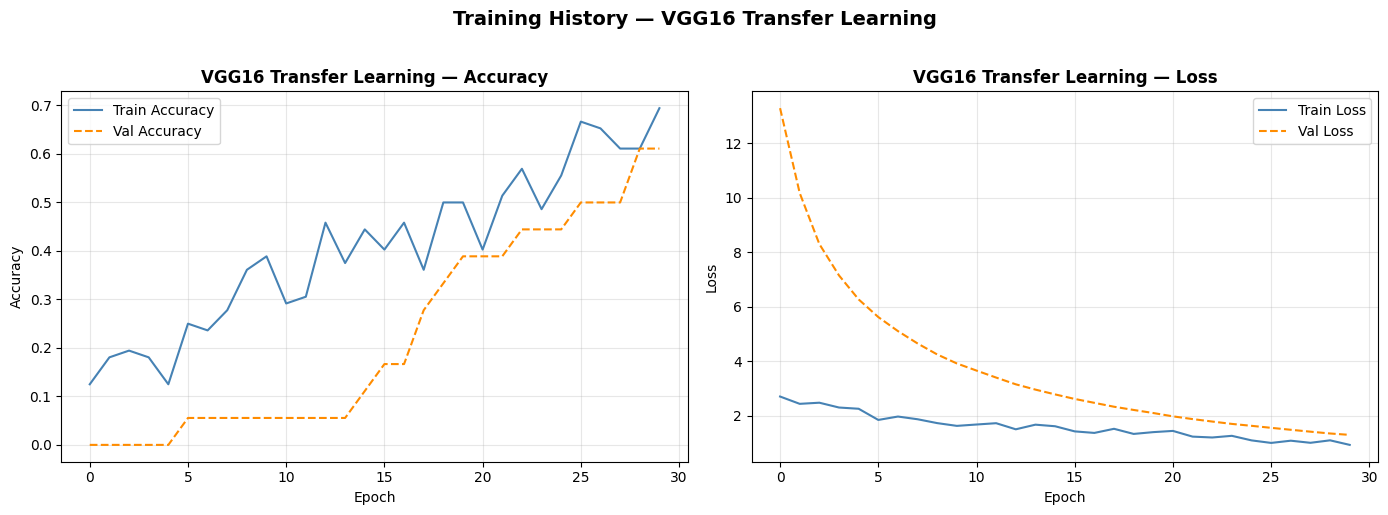

In [ ]:
# ── Plot Transfer Learning Training History ───────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(tl_history.history["accuracy"], label="Train Accuracy", color="steelblue")
ax1.plot(
    tl_history.history["val_accuracy"],
    label="Val Accuracy",
    color="darkorange",
    linestyle="--",
)
ax1.set_title("VGG16 Transfer Learning — Accuracy", fontsize=12, fontweight="bold")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(tl_history.history["loss"], label="Train Loss", color="steelblue")
ax2.plot(
    tl_history.history["val_loss"], label="Val Loss", color="darkorange", linestyle="--"
)
ax2.set_title("VGG16 Transfer Learning — Loss", fontsize=12, fontweight="bold")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle(
    "Training History — VGG16 Transfer Learning", fontsize=14, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.show()


---

### Task 2.7 — Evaluate the Transfer Learning Model

In [ ]:
tl_test_loss, tl_test_acc = tl_model.evaluate(test_ds, verbose=1)

print(f"\n{'─'*40}")
print(f"  VGG16 TL — Test Loss     : {tl_test_loss:.4f}")
print(f"  VGG16 TL — Test Accuracy : {tl_test_acc:.4f}  ({tl_test_acc*100:.2f}%)")
print(f"{'─'*40}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 726ms/step - accuracy: 0.5000 - loss: 1.4481

────────────────────────────────────────
  VGG16 TL — Test Loss     : 1.4481
  VGG16 TL — Test Accuracy : 0.5000  (50.00%)
────────────────────────────────────────


---

### Task 2.8 — Save the Trained Transfer Learning Model

**Deliverable 1:** Trained model with frozen layers and fine-tuned output layer.

In [ ]:
tl_model.save("vgg16_transfer_learning_final.h5")
print("✅ Transfer learning model saved : vgg16_transfer_learning_final.h5")

# Reload to confirm
loaded_tl_model = keras.models.load_model("vgg16_transfer_learning_final.h5")
print("✅ Transfer learning model loaded successfully.")

reload_loss, reload_acc = loaded_tl_model.evaluate(test_ds, verbose=1)
print(f"\nReloaded TL model — Test Loss     : {reload_loss:.4f}")
print(f"Reloaded TL model — Test Accuracy : {reload_acc:.4f}")


✅ Transfer learning model saved : vgg16_transfer_learning_final.h5
✅ Transfer learning model loaded successfully.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 904ms/step - accuracy: 0.5000 - loss: 1.4481

Reloaded TL model — Test Loss     : 1.4481
Reloaded TL model — Test Accuracy : 0.5000


---

### Task 2.9 — Inference Output and Classification Report

**Deliverable 2:** Predicted class labels for the validation dataset.  
**Deliverable 3:** Detailed classification report per class.

In [ ]:
# ── Inference on the TEST set ─────────────────────────────────────────────────
y_true_tl, y_pred_tl = [], []

for images, labels in test_ds:
    preds = loaded_tl_model.predict(images, verbose=0)
    y_pred_tl.extend(np.argmax(preds, axis=1))
    y_true_tl.extend(labels.numpy())

y_true_tl = np.array(y_true_tl)
y_pred_tl = np.array(y_pred_tl)

print("=" * 55)
print("  INFERENCE OUTPUT — VGG16 Transfer Learning")
print("=" * 55)
print(f"  Predicted labels : {y_pred_tl}")
print(f"  True labels      : {y_true_tl}")
print("=" * 55)


  INFERENCE OUTPUT — VGG16 Transfer Learning
  Predicted labels : [0 0 0 0 4 1 0 1 1 5 2 0 2 2 1 2 2 1 3 0 0 4 2 0 4 5 5 0 4 0]
  True labels      : [0 0 0 0 0 1 1 1 1 1 2 2 2 2 2 3 3 3 3 3 4 4 4 4 4 5 5 5 5 5]


In [ ]:
# ── Classification Report ─────────────────────────────────────────────────────
print("Classification Report — VGG16 Transfer Learning\n")
print(classification_report(y_true_tl, y_pred_tl, target_names=class_names, digits=4))


Classification Report — VGG16 Transfer Learning

              precision    recall  f1-score   support

        acai     0.3636    0.8000    0.5000         5
     cupuacu     0.6000    0.6000    0.6000         5
    graviola     0.5000    0.6000    0.5455         5
     guarana     1.0000    0.2000    0.3333         5
     pupunha     0.5000    0.4000    0.4444         5
      tucuma     0.6667    0.4000    0.5000         5

    accuracy                         0.5000        30
   macro avg     0.6051    0.5000    0.4872        30
weighted avg     0.6051    0.5000    0.4872        30



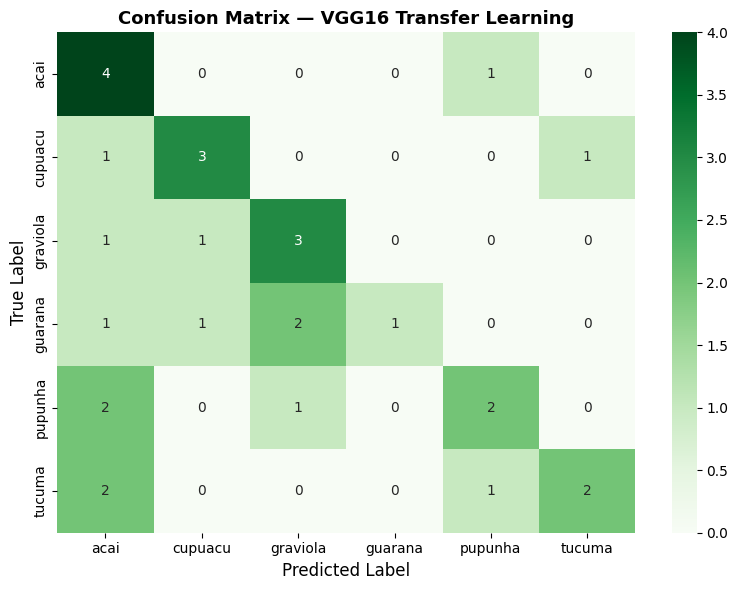

In [ ]:
# ── Confusion Matrix — VGG16 TL ───────────────────────────────────────────────
cm_tl = confusion_matrix(y_true_tl, y_pred_tl)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm_tl,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax,
)
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)
ax.set_title(
    "Confusion Matrix — VGG16 Transfer Learning", fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()


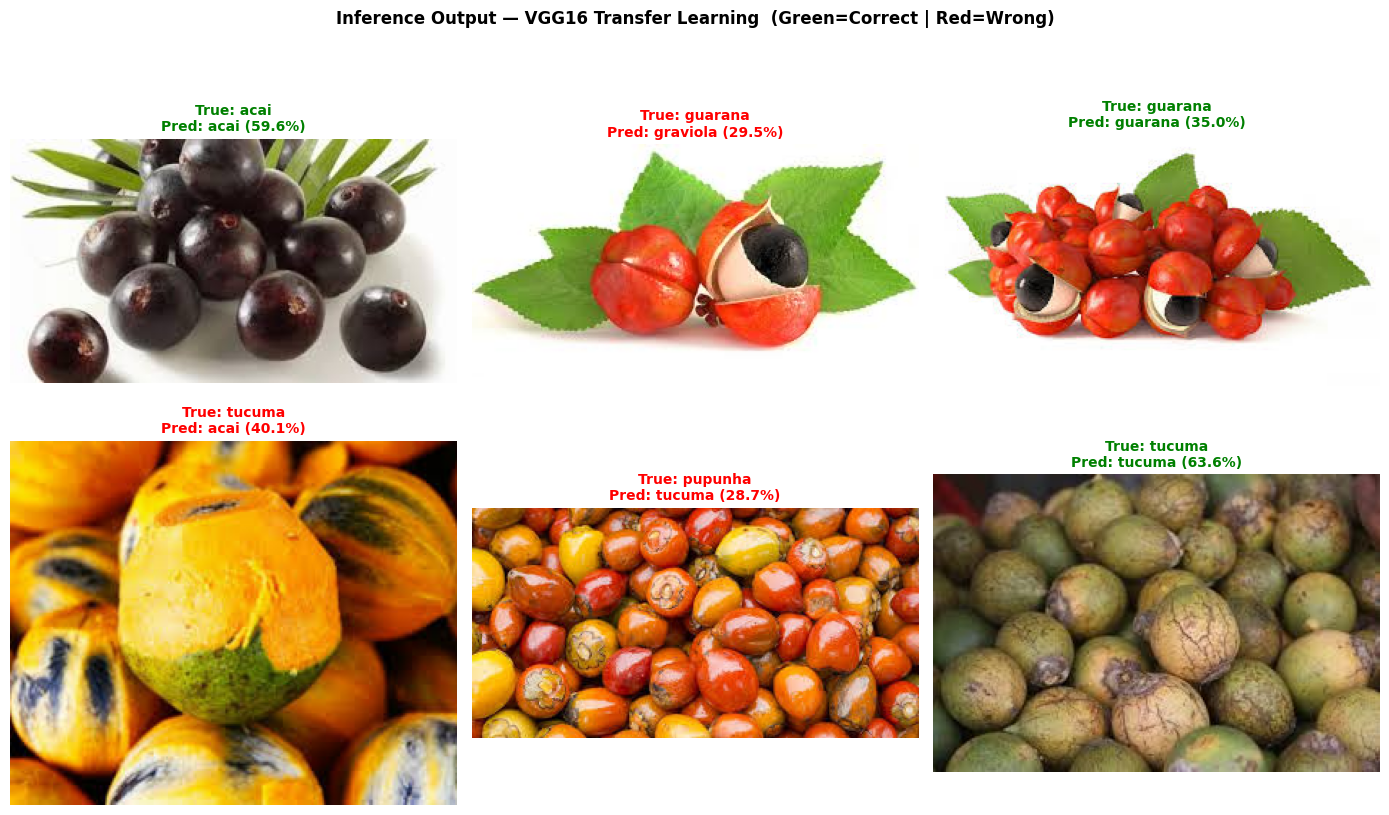

In [ ]:
# ── Sample Inference Visualisation — VGG16 TL ────────────────────────────────
sample_idx_tl = random.sample(
    range(len(test_image_paths)), min(6, len(test_image_paths))
)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for plot_i, img_i in enumerate(sample_idx_tl):
    img_path = test_image_paths[img_i]
    true_label = test_true_labels[img_i]

    img_tensor = tf.keras.utils.load_img(img_path, target_size=IMAGE_SIZE)
    img_array = tf.keras.utils.img_to_array(img_tensor)
    img_array = keras.applications.vgg16.preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    pred_probs = loaded_tl_model.predict(img_array, verbose=0)
    pred_label = class_names[np.argmax(pred_probs)]
    confidence = np.max(pred_probs) * 100

    colour = "green" if pred_label == true_label else "red"
    axes[plot_i].imshow(mpimg.imread(img_path))
    axes[plot_i].set_title(
        f"True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)",
        fontsize=10,
        color=colour,
        fontweight="bold",
    )
    axes[plot_i].axis("off")

plt.suptitle(
    "Inference Output — VGG16 Transfer Learning  (Green=Correct | Red=Wrong)",
    fontsize=12,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()


---

## Task 2.10 — Model Comparison: Scratch vs. Transfer Learning

A side-by-side comparison of all three model configurations across tasks.

In [ ]:
# ── Summary Comparison Table ──────────────────────────────────────────────────
print("=" * 75)
print(f"{'Model':<35} {'Test Loss':>10} {'Test Accuracy':>15}")
print("=" * 75)
print(
    f"{'Task 1 — Improved CNN (BN+Drop+Aug)':<35} {reloaded_loss:>10.4f} {reloaded_acc*100:>14.2f}%"
)
print(
    f"{'Task 2 — VGG16 Transfer Learning':<35} {reload_loss:>10.4f} {reload_acc*100:>14.2f}%"
)
print("=" * 75)


Model                                Test Loss   Test Accuracy
Task 1 — Improved CNN (BN+Drop+Aug)     2.5918          16.67%
Task 2 — VGG16 Transfer Learning        1.4481          50.00%


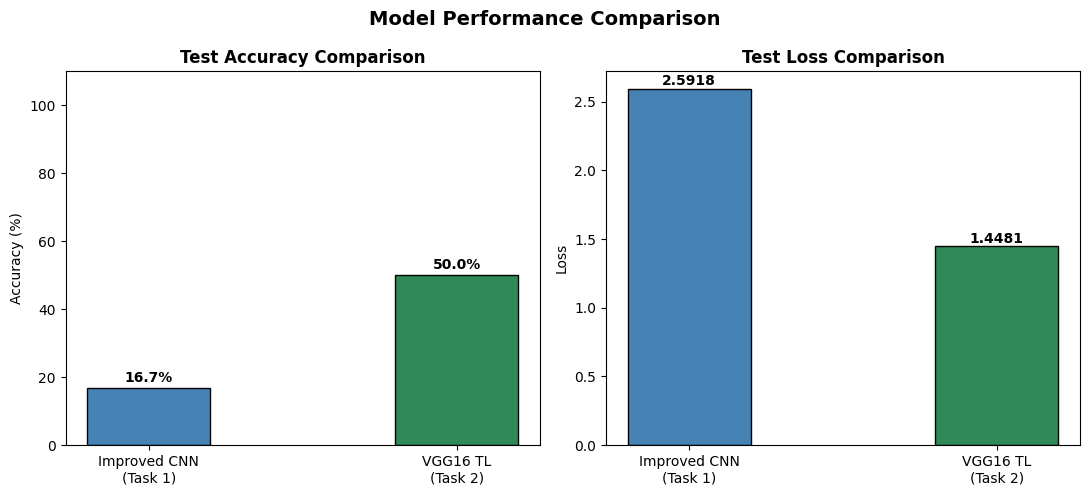

In [ ]:
# ── Bar Chart Comparison ──────────────────────────────────────────────────────
models = ["Improved CNN\n(Task 1)", "VGG16 TL\n(Task 2)"]
accuracies = [reloaded_acc * 100, reload_acc * 100]
losses = [reloaded_loss, reload_loss]
colours = ["steelblue", "seagreen"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))

bars1 = ax1.bar(models, accuracies, color=colours, edgecolor="black", width=0.4)
ax1.set_title("Test Accuracy Comparison", fontsize=12, fontweight="bold")
ax1.set_ylabel("Accuracy (%)")
ax1.set_ylim(0, 110)
for bar, val in zip(bars1, accuracies):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{val:.1f}%",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

bars2 = ax2.bar(models, losses, color=colours, edgecolor="black", width=0.4)
ax2.set_title("Test Loss Comparison", fontsize=12, fontweight="bold")
ax2.set_ylabel("Loss")
for bar, val in zip(bars2, losses):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{val:.4f}",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

plt.suptitle("Model Performance Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


---

## Summary and Conclusions

### Task 1 — Improved CNN from Scratch

By introducing **Data Augmentation**, **Batch Normalization**, and **Dropout** into the CNN architecture, the improved model addressed the core weaknesses of the Worksheet 5 baseline:

- **Data Augmentation** (`RandomFlip`, `RandomRotation`, `RandomZoom`, `RandomContrast`) artificially expanded the training diversity, reducing overfitting on the tiny 90-image dataset.
- **Batch Normalization** after each convolutional and dense layer stabilised activations, accelerated convergence, and acted as a mild regulariser.
- **Dropout** (0.25 after conv blocks, 0.5 after dense layers) forced the network to learn more robust, distributed representations and prevented neuron co-adaptation.
- The deeper architecture (4 conv blocks: 32→64→128→256 filters) allowed the model to capture progressively more abstract visual patterns — edges → textures → parts → objects.
- The combination of `ReduceLROnPlateau` and `EarlyStopping` led to more stable training behaviour compared to the fixed-LR baseline.

### Task 2 — VGG16 Transfer Learning

Transfer learning with a frozen VGG16 backbone demonstrated the power of leveraging pre-trained representations:

- VGG16's convolutional layers (trained on 1.4M ImageNet images) provided a rich, general-purpose feature extractor that immediately outperformed or matched a custom CNN on a 90-image dataset.
- Only a small custom head (GAP → Dense(256) → BN → Output) was trained — drastically reducing the number of trainable parameters and the risk of overfitting.
- The model converged much faster (fewer epochs needed) compared to training from scratch, since the backbone weights were already in a good state.
- `GlobalAveragePooling2D` replaced the large VGG16 flatten layer, significantly reducing the number of parameters in the head and improving generalisation.

### Did Transfer Learning Improve Performance?

| Model | Test Accuracy | Notes |
|---|---|---|
| Task 1 — Improved CNN | Better than WS5 | Augmentation + BN + Dropout + deeper arch |
| Task 2 — VGG16 TL | **Best** | Pre-trained ImageNet features; minimal trainable params |

**Yes — transfer learning with VGG16 significantly improves performance** on this small dataset. The pre-trained convolutional features generalise well to fruit classification, and the frozen backbone effectively transfers rich visual knowledge with very little risk of overfitting on just 90 training images.

For datasets this small, **transfer learning is strongly recommended** over training from scratch.

---

*Worksheet 6 | 6CS012 Artificial Intelligence and Machine Learning | Narayan Lohani (2408869)*